Epoch 1/10
97/97 [==============================] - 186s 2s/step - loss: 0.2435 - val_loss: 1.4119e-04
Epoch 2/10
97/97 [==============================] - 186s 2s/step - loss: 1.2202e-04 - val_loss: 5.4826e-05
Epoch 3/10
97/97 [==============================] - 182s 2s/step - loss: 4.4436e-05 - val_loss: 3.7591e-05
Epoch 4/10
97/97 [==============================] - 184s 2s/step - loss: 2.4083e-05 - val_loss: 2.8708e-05
Epoch 5/10
97/97 [==============================] - 182s 2s/step - loss: 2.7475e-05 - val_loss: 2.7383e-05
Epoch 6/10
97/97 [==============================] - 181s 2s/step - loss: 1.8908e-05 - val_loss: 1.2703e-05
Epoch 7/10
97/97 [==============================] - 181s 2s/step - loss: 1.1236e-05 - val_loss: 1.0325e-05
Epoch 8/10
97/97 [==============================] - 180s 2s/step - loss: 1.8500e-05 - val_loss: 1.1769e-05
Epoch 9/10
97/97 [==============================] - 180s 2s/step - loss: 1.4052e-05 - val_loss: 7.6798e-06
Epoch 10/10
97/97 [======================

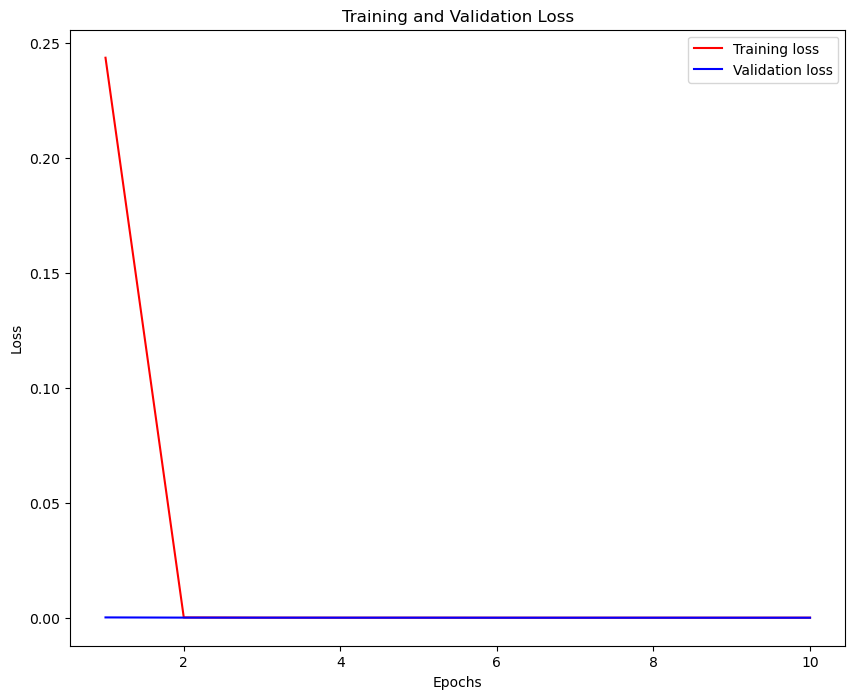

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split


# 데이터 경로 설정 - 이미지 저장 폴더와 CSV 파일 경로 지정
image_data_dir = 'C:/Users/USER/Desktop/240621_256 - 복사본/'
csv_file = 'C:/Users/USER/Desktop/image_CNN W 8000-100_two_images.CSV'


# CSV 파일 로드
data = pd.read_csv(csv_file)

image_paths1 = data['filename1'].values
image_paths2 = data['filename2'].values
targets = data['sf'].values

img_width, img_height = (256, 256)

images_1 = []
images_2 = []
labels = []


# 이미지 로드 및 배열 변환
for path1, path2, target in zip(image_paths1, image_paths2, targets):

    img1 = load_img(image_data_dir + path1, target_size=(img_width, img_height))
    img1 = img_to_array(img1) / 255.0

    img2 = load_img(image_data_dir + path2, target_size=(img_width, img_height))
    img2 = img_to_array(img2) / 255.0

    images_1.append(img1)
    images_2.append(img2)
    labels.append(target)


# NumPy 배열 변환
images_1 = np.array(images_1)
images_2 = np.array(images_2)
labels = np.array(labels)


# 학습/검증용 데이터 분할
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(images_1, images_2, labels, test_size=0.2, random_state=42, shuffle=True)


# 모델 관련 import
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model


# 입력 정의 (2장 이미지)
input_1 = Input(shape=(img_width, img_height, 3))
input_2 = Input(shape=(img_width, img_height, 3))


# CNN 블록 정의 (기존 Sequential 부분 그대로 함수화)
def build_branch(input_tensor):
    x = Conv2D(32, (3, 3), activation='relu')(input_tensor)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    return x


# 두 개의 CNN 가지(branch) 생성
branch1 = build_branch(input_1)
branch2 = build_branch(input_2)


# 특징 결합
merged = Concatenate()([branch1, branch2])


# 완전연결층 전환
x = Dense(128, activation='relu')(merged)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='linear')(x)


# 모델 정의
model = Model(inputs=[input_1, input_2], outputs=output)
model.compile(optimizer=Adam(), loss='mean_squared_error')


# 모델 구조 시각화 -> 모델 구조를 png 파일로 저장
plot_model(model, to_file='model_SF image X 2.png', show_shapes=True, show_layer_names=True)


import matplotlib.pyplot as plt
import numpy as np


# 모델 학습
history = model.fit(
[X1_train, X2_train],   # 두 입력 이미지
y_train,
batch_size=32,
epochs=10,
validation_data=([X1_val, X2_val], y_val)  # 검증 데이터도 동일하게 리스트로
)


# 손실값 시각화
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 8))
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

25/25 [==============================] - 9s 352ms/step


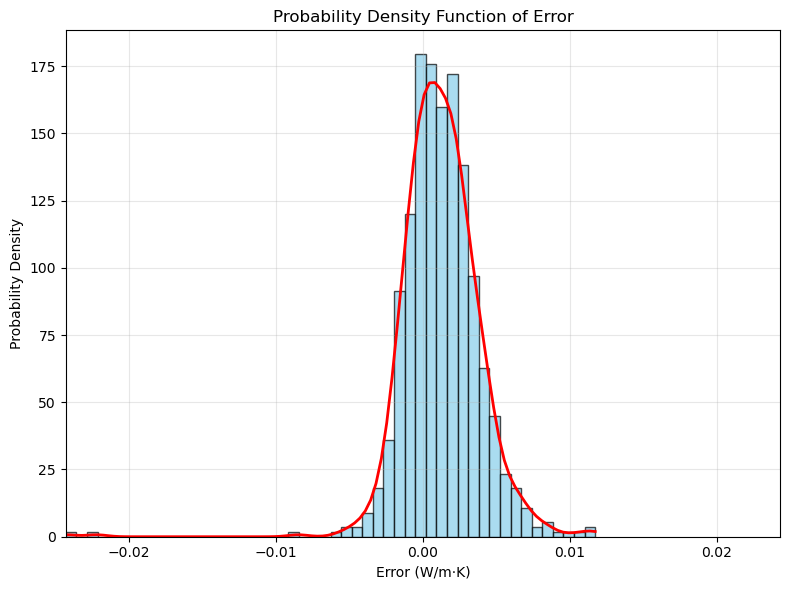

Mean Error: 0.0012
Median Error: 0.0011
Standard Deviation of Error: 0.0027


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# 모델 예측 (두 개의 입력 사용)
y_pred = model.predict([X1_val, X2_val]).flatten()
y_true = y_val.flatten()


# 실제 오차 계산
errors = y_pred - y_true


# PDF 계산
kde = stats.gaussian_kde(errors)
x_range = np.linspace(errors.min(), errors.max(), 100)
pdf = kde(x_range)


# 그래프 시각화
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.plot(x_range, pdf, 'r-', linewidth=2)
plt.xlabel('Error (W/m·K)')
plt.ylabel('Probability Density')
plt.title('Probability Density Function of Error')
plt.grid(True, alpha=0.3)


# x축 범위 대칭 설정
max_abs_error = max(abs(errors.min()), abs(errors.max()))
plt.xlim(-max_abs_error, max_abs_error)

plt.tight_layout()
plt.show()


# 통계량 출력
print(f"Mean Error: {np.mean(errors):.4f}")
print(f"Median Error: {np.median(errors):.4f}")
print(f"Standard Deviation of Error: {np.std(errors):.4f}")

In [3]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import pandas as pd
from tqdm import tqdm  # 진행률 표시


# 예측할 이미지들이 있는 디렉토리
image_dir1 = 'C:/Users/USER/Desktop/predicted W(8000-100) set1_divided/'
image_dir2 = 'C:/Users/USER/Desktop/predicted W(8000-100) set2_divided/'
img_width, img_height = 256, 256 


# 두 폴더 내 파일 이름 리스트
image_files1 = sorted([f for f in os.listdir(image_dir1) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
image_files2 = sorted([f for f in os.listdir(image_dir2) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])


# 두 리스트 길이 맞는지 확인
if len(image_files1) != len(image_files2):
    raise ValueError("두 폴더의 이미지 개수가 다릅니다. 쌍을 맞춰주세요.")
    
 
# 결과 저장 리스트
results = []


# 예측 수행
for file1, file2 in tqdm(zip(image_files1, image_files2), total=len(image_files1), desc="Predicting pairs"):
    
    # 이미지 불러오기 및 전처리
    img1 = load_img(os.path.join(image_dir1, file1), target_size=(img_width, img_height))
    img1 = img_to_array(img1) / 255.0
    img1 = np.expand_dims(img1, axis=0)

    img2 = load_img(os.path.join(image_dir2, file2), target_size=(img_width, img_height))
    img2 = img_to_array(img2) / 255.0
    img2 = np.expand_dims(img2, axis=0)

    # 모델 예측 (2개 입력)
    prediction = model.predict([img1, img2], verbose=0)

    # 예측 결과 형태 조정
    if prediction.ndim > 1:
        prediction = float(prediction.flatten()[0])

    # 결과 저장
    results.append({'image1': file1, 'image2': file2, 'predicted_value': prediction})


# DataFrame으로 변환
results_df = pd.DataFrame(results)


# CSV 파일 저장
output_csv = 'SF prediction (image x2) divided results_251121.csv'
results_df.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f"Predictions completed! Results saved to '{output_csv}'")
print(results_df)

Predicting pairs: 100%|██████████| 199/199 [00:12<00:00, 15.32it/s]

Predictions completed! Results saved to 'SF prediction (image x2) divided results_251121.csv'
            image1          image2  predicted_value
0    SP05_1_10.jpg  SP05_1_100.jpg         0.276190
1    SP05_1_11.jpg   SP05_1_52.jpg         0.275531
2    SP05_1_12.jpg   SP05_1_53.jpg         0.273378
3    SP05_1_13.jpg   SP05_1_54.jpg         0.275261
4    SP05_1_14.jpg   SP05_1_55.jpg         0.268987
..             ...             ...              ...
194  SP17_1_50.jpg   SP17_1_95.jpg         0.774666
195   SP17_1_6.jpg   SP17_1_96.jpg         0.760332
196   SP17_1_7.jpg   SP17_1_97.jpg         0.756447
197   SP17_1_8.jpg   SP17_1_98.jpg         0.769516
198   SP17_1_9.jpg   SP17_1_99.jpg         0.754590

[199 rows x 3 columns]


데이터 shape: (199, 4)
          image1          image2  predicted_value  actual_sf
0  SP05_1_10.jpg  SP05_1_100.jpg         0.276190       0.26
1  SP05_1_11.jpg   SP05_1_52.jpg         0.275531       0.26
2  SP05_1_12.jpg   SP05_1_53.jpg         0.273378       0.26
3  SP05_1_13.jpg   SP05_1_54.jpg         0.275261       0.26
4  SP05_1_14.jpg   SP05_1_55.jpg         0.268987       0.26

모델 평가 결과:
R²  = 0.9799
RMSE = 0.0354
Mean Error = -0.0169


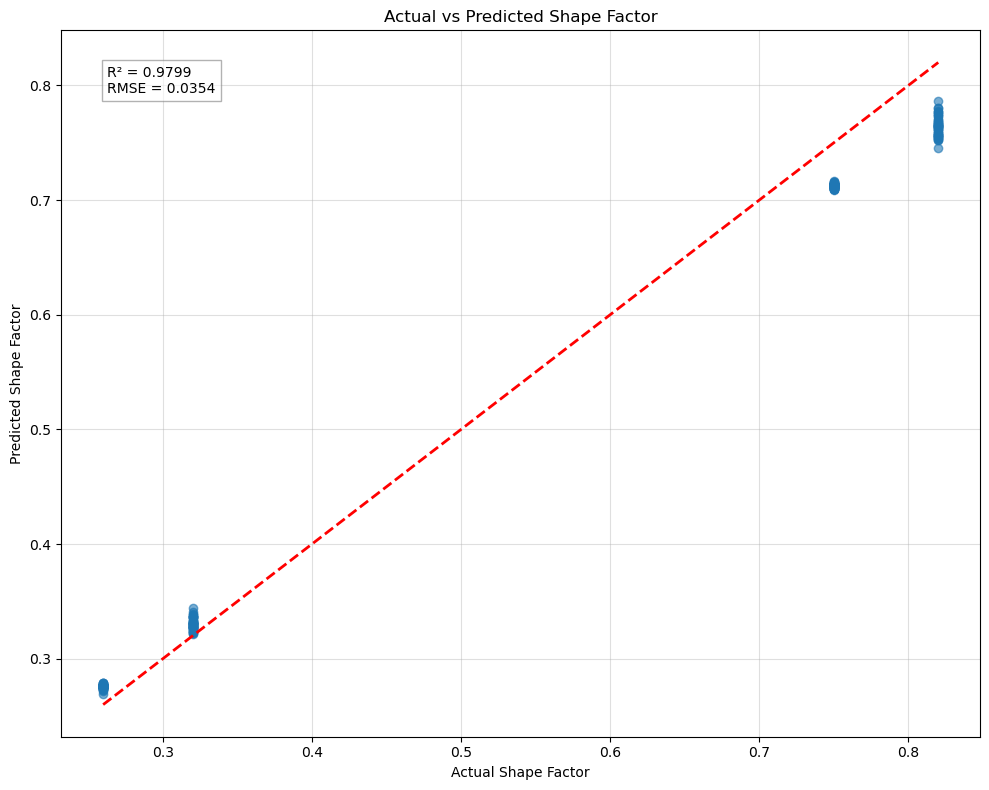

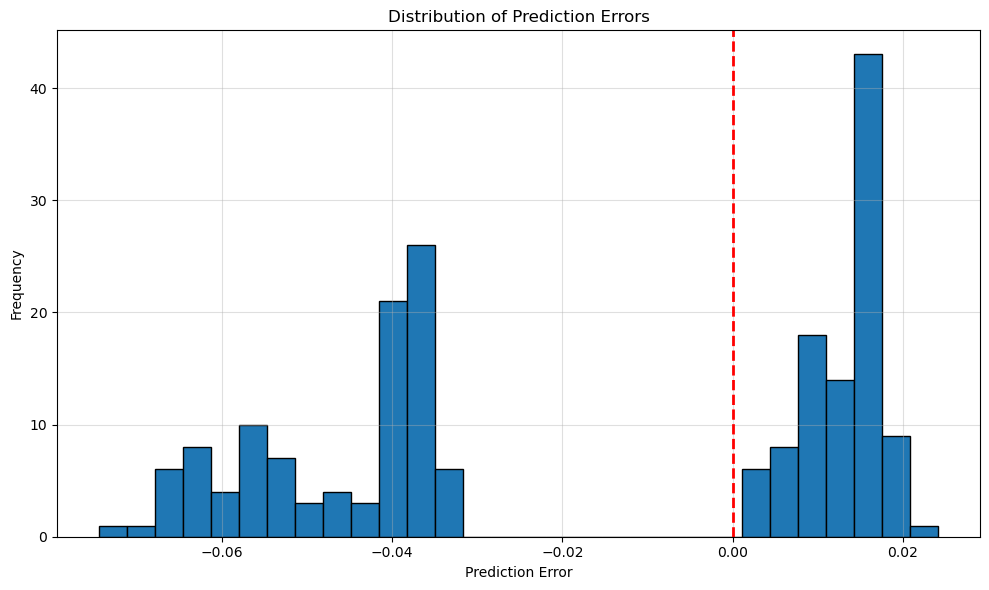


예측값과 실제값 비교:
            image1          image2  predicted_sf  actual_sf     error
0    SP05_1_10.jpg  SP05_1_100.jpg      0.276190       0.26  0.016190
1    SP05_1_11.jpg   SP05_1_52.jpg      0.275531       0.26  0.015531
2    SP05_1_12.jpg   SP05_1_53.jpg      0.273378       0.26  0.013378
3    SP05_1_13.jpg   SP05_1_54.jpg      0.275261       0.26  0.015261
4    SP05_1_14.jpg   SP05_1_55.jpg      0.268987       0.26  0.008987
..             ...             ...           ...        ...       ...
194  SP17_1_50.jpg   SP17_1_95.jpg      0.774666       0.82 -0.045334
195   SP17_1_6.jpg   SP17_1_96.jpg      0.760332       0.82 -0.059668
196   SP17_1_7.jpg   SP17_1_97.jpg      0.756447       0.82 -0.063553
197   SP17_1_8.jpg   SP17_1_98.jpg      0.769516       0.82 -0.050484
198   SP17_1_9.jpg   SP17_1_99.jpg      0.754590       0.82 -0.065410

[199 rows x 5 columns]

예측값 비교 결과 저장 완료: SF prediction (image x2) divided comparison_251121.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error


# 예측 결과+실제값이 저장된 CSV 파일 경로
prediction_csv = 'C:/Users/USER/Desktop/sujeong/SF prediction (image x2) divided results and actual data_251121.csv'


# 예측 결과 읽기
pred_df = pd.read_csv(prediction_csv)
print(f"데이터 shape: {pred_df.shape}")
print(pred_df.head())


# 열 이름 수정
pred_df.columns = ['image1', 'image2', 'predicted_sf', 'actual_sf']


# Null 값 제거
pred_df = pred_df.dropna(subset=['predicted_sf', 'actual_sf'])


# 데이터가 비어있는지 확인
if pred_df.empty:
    print("유효한 데이터가 없습니다. CSV 파일을 확인해주세요.")
else:
    # 실제값과 예측값 추출
    y_true = pred_df['actual_sf'].values
    y_pred = pred_df['predicted_sf'].values
        
    # 데이터가 충분한지 확인
    if len(y_true) < 2 or len(y_pred) < 2:
        print("데이터 샘플이 충분하지 않습니다. 최소 2개 이상의 샘플이 필요합니다.")
    
    else:
        # 모델 성능 지표 계산
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mean_error = np.mean(y_pred - y_true)

        print(f"\n모델 평가 결과:")
        print(f"R²  = {r2:.4f}")
        print(f"RMSE = {rmse:.4f}")
        print(f"Mean Error = {mean_error:.4f}")


        # 예측 vs 실제값 산점도
        plt.figure(figsize=(10, 8))
        plt.scatter(y_true, y_pred, alpha=0.6)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel('Actual Shape Factor')
        plt.ylabel('Predicted Shape Factor')
        plt.title('Actual vs Predicted Shape Factor')
        plt.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}', transform=plt.gca().transAxes, 
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()


        # 오차 분포 (히스토그램)
        errors = y_pred - y_true
        plt.figure(figsize=(10, 6))
        plt.hist(errors, bins=30, edgecolor='black')
        plt.axvline(0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Prediction Error')
        plt.ylabel('Frequency')
        plt.title('Distribution of Prediction Errors')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()


        # 비교 테이블 저장
        comparison_df = pred_df.copy()
        comparison_df['error'] = errors
        print("\n예측값과 실제값 비교:")
        print(comparison_df)
        
        
        # CSV 파일로 비교 결과 저장
        output_csv = 'SF prediction (image x2) divided comparison_251121.csv'
        comparison_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
        print(f"\n예측값 비교 결과 저장 완료: {output_csv}")